# HLS Example (https)

The Harmonized Landsat Sentinel 2 dataset contains grid-aligned cloud-optimized geotiffs that are great for deep time series analysis because it contains the combined archives from Landsat 8/9 and Sentinel 2A/B/C. NASA MAAP maintains a [stac-geoparquet archive](https://maap-project.github.io/hls-stac-geoparquet-archive/) of all of the HLS STAC records. This archive solves a common bottleneck that users have encountered when trying to work with HLS STAC records at scale by eliminating the need to query the CMR STAC API!

This notebook demonstrates how to use lazycogs to interact with the HLS STAC Geoparquet Archive in the optimal way.

**Note:** This tutorial shows how to access the HLS granules using https links. If you are able to run your compute in the AWS us-west-2 region, try the method outlined in [HLS Example (us-west-2 only)](./hls-s3.ipynb).

In [31]:
import os
from urllib.parse import urlparse

import requests
import rustac
from async_geotiff import GeoTIFF
from obstore.store import HTTPStore
from pyproj import Transformer

import lazycogs

HLS_STAC_GEOPARQUET_HREF = "s3://nasa-maap-data-store/file-staging/nasa-map/hls-stac-geoparquet-archive/v2/{collection}/year={year}/month={month}/{collection}-{year}-{month}.parquet"

### Define the array extent

The HLS granules are projected in UTM coordinate reference systems. To access the underlying data in an undistorted efficient manner the best way is to build an array for a single UTM coordinate system that is aligned with the grid of the COGs themselves.

We can define an AOI for an entire UTM zone like this:

In [32]:
epsg_code = "32615"
utm_zone = 15
dst_crs = f"epsg:{epsg_code}"

east_edge = (utm_zone * 6) - 180
west_edge = east_edge - 6
bbox_4326 = (west_edge, 0, east_edge, 84)

# transform to epsg:4326 for STAC search
transformer = Transformer.from_crs("epsg:4326", dst_crs, always_xy=True)
dst_bbox = transformer.transform_bounds(*bbox_4326)

print(bbox_4326)
print(dst_bbox)

(-96, 0, -90, 84)
(166021.44308053772, 0.0, 833978.5569194595, 9329005.182447437)


Retrieve a single STAC item so we can snap our approximate bounding box to the HLS granule grid.

In [33]:
sample_item = rustac.search_sync(
    HLS_STAC_GEOPARQUET_HREF.format(collection="HLSS30_2.0", year=2026, month=3),
    bbox=bbox_4326,
    filter={"op": "=", "args": [{"property": "proj:epsg"}, epsg_code]},
    max_items=1,
)[0]

Use the `proj:transform` property to align our rough bounding box with the HLS grid

In [34]:
dst_bbox_aligned = lazycogs.align_bbox(
    sample_item["properties"]["proj:transform"],
    dst_bbox,
)

print(f"aligned bbox: {dst_bbox_aligned}")

aligned bbox: (166020.0, 0.0, 834000.0, 9329010.0)


### Configure access to the HLS COGs over HTTP

The STAC assets in the stac-geoparquet file contain `https` hrefs but they require an EDL token to access. obstore's `HTTPStore` allows you to provide the `Authorization: Bearer <token>` header via `default_headers` in the `client_options` dict.

This will work for you if you have your NASA Earthdata credentials stored in the `EARTHDATA_USERNAME` and `EARTHDATA_PASSWORD` environment variables.

In [35]:
def get_earthdata_token(username: str, password: str) -> str:
    r = requests.post(
        "https://urs.earthdata.nasa.gov/api/users/find_or_create_token",
        auth=(username, password),
        timeout=10,
    )
    r.raise_for_status()
    return r.json()["access_token"]


token = get_earthdata_token(
    os.getenv("EARTHDATA_USERNAME"),
    os.getenv("EARTHDATA_PASSWORD"),
)

store_prefix = "https://data.lpdaac.earthdatacloud.nasa.gov"

store = HTTPStore(
    store_prefix,
    client_options={
        "default_headers": {
            "Authorization": f"Bearer {token}",
        },
    },
)

### Inspect a sample COG

We can use async-geotiff to inspect a sample COG and its overviews:

In [38]:
geotiff = await GeoTIFF.open(
    urlparse(sample_item["assets"]["B04"]["href"]).path,
    store=store,
)

resolutions = [geotiff.res[0]]
print("full resolution:", geotiff.res)

for i, overview in enumerate(geotiff.overviews, start=1):
    resolutions.append(overview.res[0])
    print("overview", i, overview.res)

print("nodata value:", geotiff.nodata)
print("data type:", geotiff.dtype)

full resolution: (30.0, 30.0)
overview 1 (60.0, 60.0)
overview 2 (120.0, 120.0)
overview 3 (239.73799126637556, 239.73799126637556)
overview 4 (479.4759825327511, 479.4759825327511)
nodata value: -9999.0
data type: int16


### Open a massive array

Now open an array for the full resolution data for the year 2025. To load a lower-resolution array you can select a different value from the `resolutions` list and lazycogs will use the COGs' overviews instead of the full-resolution data. If you pick something in between one of the listed resolutions lazycogs will have to warp the arrays and do a nearest-neighbor interpolation.

In [39]:
stac_search_args = {
    "href": HLS_STAC_GEOPARQUET_HREF.format(
        collection="HLSS30_2.0",
        year=2026,
        month=3,
    ),
    "datetime": "2026-03-01T00:00:00Z/2026-03-31T23:59:59Z",
    "filter": {"op": "=", "args": [{"property": "proj:epsg"}, epsg_code]},
}

da = lazycogs.open(
    crs=dst_crs,
    bbox=dst_bbox_aligned,
    resolution=30,
    time_period="P1D",  # one time coordinate per day
    bands=["B04", "B03", "B02"],
    dtype=geotiff.dtype,
    nodata=geotiff.nodata,
    store=store,
    **stac_search_args,
)

da

<xarray.DataArray (band: 3, time: 31, y: 310967, x: 22266)> Size: 1TB
[643931183646 values with dtype=int16]
Coordinates:
  * band         (band) <U3 36B 'B04' 'B03' 'B02'
  * time         (time) datetime64[s] 248B 2026-03-01 2026-03-02 ... 2026-03-31
  * y            (y) float64 2MB 9.329e+06 9.329e+06 9.329e+06 ... 45.0 15.0
  * x            (x) float64 178kB 1.66e+05 1.661e+05 ... 8.34e+05 8.34e+05
    spatial_ref  int64 8B 0
Indexes:
  ┌ x        RasterIndex (crs=EPSG:32615)
  └ y
Attributes:
    grid_mapping:            spatial_ref
    zarr_conventions:        [{'schema_url': 'https://raw.githubusercontent.c...
    spatial:dimensions:      ['y', 'x']
    spatial:bbox:            (166020.0, 0.0, 834000.0, 9329010.0)
    spatial:transform_type:  affine
    spatial:transform:       [30.0, 0.0, 166020.0, 0.0, -30.0, 9329010.0]
    spatial:shape:           [310967, 22266]
    spatial:registration:    pixel
    _stac_backend:           MultiBandStacBackendArray(bands=['B04', 'B03', '...
    _stac_time_coords:       2026-03-01 … 2026-03-31 (n=31)
    proj:code:               EPSG:32615

Extract all values for a single point.

In [40]:
%%time
pt = da.sel(
    x=576465,
    y=5196159,
    method="nearest",
).load()

pt

CPU times: user 9.54 s, sys: 3.08 s, total: 12.6 s
Wall time: 35.5 s


<xarray.DataArray (band: 3, time: 31)> Size: 186B
array([[ 7986, -9999, -9999,  6964, -9999, -9999, -9999, -9999,  5051,
        -9999,  8024, -9999, -9999,  5425, -9999,  6673, -9999, -9999,
         5598, -9999,  4397, -9999, -9999,  4471, -9999,  9150, -9999,
        -9999,  4299, -9999,  8252],
       [ 7776, -9999, -9999,  6768, -9999, -9999, -9999, -9999,  4606,
        -9999,  8037, -9999, -9999,  5589, -9999,  6615, -9999, -9999,
         5712, -9999,  4379, -9999, -9999,  4459, -9999,  9458, -9999,
        -9999,  3990, -9999,  8129],
       [ 7363, -9999, -9999,  6262, -9999, -9999, -9999, -9999,  3945,
        -9999,  7726, -9999, -9999,  5605, -9999,  6362, -9999, -9999,
         5429, -9999,  4289, -9999, -9999,  4215, -9999,  9473, -9999,
        -9999,  3653, -9999,  8134]], dtype=int16)
Coordinates:
  * band         (band) <U3 36B 'B04' 'B03' 'B02'
  * time         (time) datetime64[s] 248B 2026-03-01 2026-03-02 ... 2026-03-31
    spatial_ref  int64 8B 0
    x            float64 8B 5.765e+05
    y            float64 8B 5.196e+06
Attributes:
    grid_mapping:            spatial_ref
    zarr_conventions:        [{'schema_url': 'https://raw.githubusercontent.c...
    spatial:dimensions:      ['y', 'x']
    spatial:bbox:            (166020.0, 0.0, 834000.0, 9329010.0)
    spatial:transform_type:  affine
    spatial:transform:       [30.0, 0.0, 166020.0, 0.0, -30.0, 9329010.0]
    spatial:shape:           [310967, 22266]
    spatial:registration:    pixel
    _stac_backend:           MultiBandStacBackendArray(bands=['B04', 'B03', '...
    _stac_time_coords:       2026-03-01 … 2026-03-31 (n=31)
    proj:code:               EPSG:32615

### Operate on a subset in space and time

Select a spatial subset for the days with non-nodata values in the point extraction.

In [28]:
subset = da.sel(
    x=slice(550_000, 600_000),
    y=slice(5_200_000, 5_150_000),
    time=pt.time.values[pt.isel(band=0).values != geotiff.nodata],
)
subset

<xarray.DataArray (band: 3, time: 12, y: 1668, x: 1668)> Size: 200MB
[100160064 values with dtype=int16]
Coordinates:
  * band         (band) <U3 36B 'B04' 'B03' 'B02'
  * time         (time) datetime64[s] 96B 2026-03-01 2026-03-04 ... 2026-03-31
  * y            (y) float64 13kB 5.2e+06 5.2e+06 5.2e+06 ... 5.15e+06 5.15e+06
  * x            (x) float64 13kB 5.5e+05 5.5e+05 5.501e+05 ... 6e+05 6e+05
    spatial_ref  int64 8B 0
Indexes:
  ┌ x        RasterIndex (crs=EPSG:32615)
  └ y
Attributes:
    grid_mapping:            spatial_ref
    zarr_conventions:        [{'schema_url': 'https://raw.githubusercontent.c...
    spatial:dimensions:      ['y', 'x']
    spatial:bbox:            (166020.0, 0.0, 834000.0, 9329010.0)
    spatial:transform_type:  affine
    spatial:transform:       [30.0, 0.0, 166020.0, 0.0, -30.0, 9329010.0]
    spatial:shape:           [310967, 22266]
    spatial:registration:    pixel
    _stac_backend:           MultiBandStacBackendArray(bands=['B04', 'B03', '...
    _stac_time_coords:       2026-03-01 … 2026-03-31 (n=31)
    proj:code:               EPSG:32615

In [29]:
%%time
_ = subset.load()

CPU times: user 17.1 s, sys: 7.23 s, total: 24.3 s
Wall time: 40.7 s


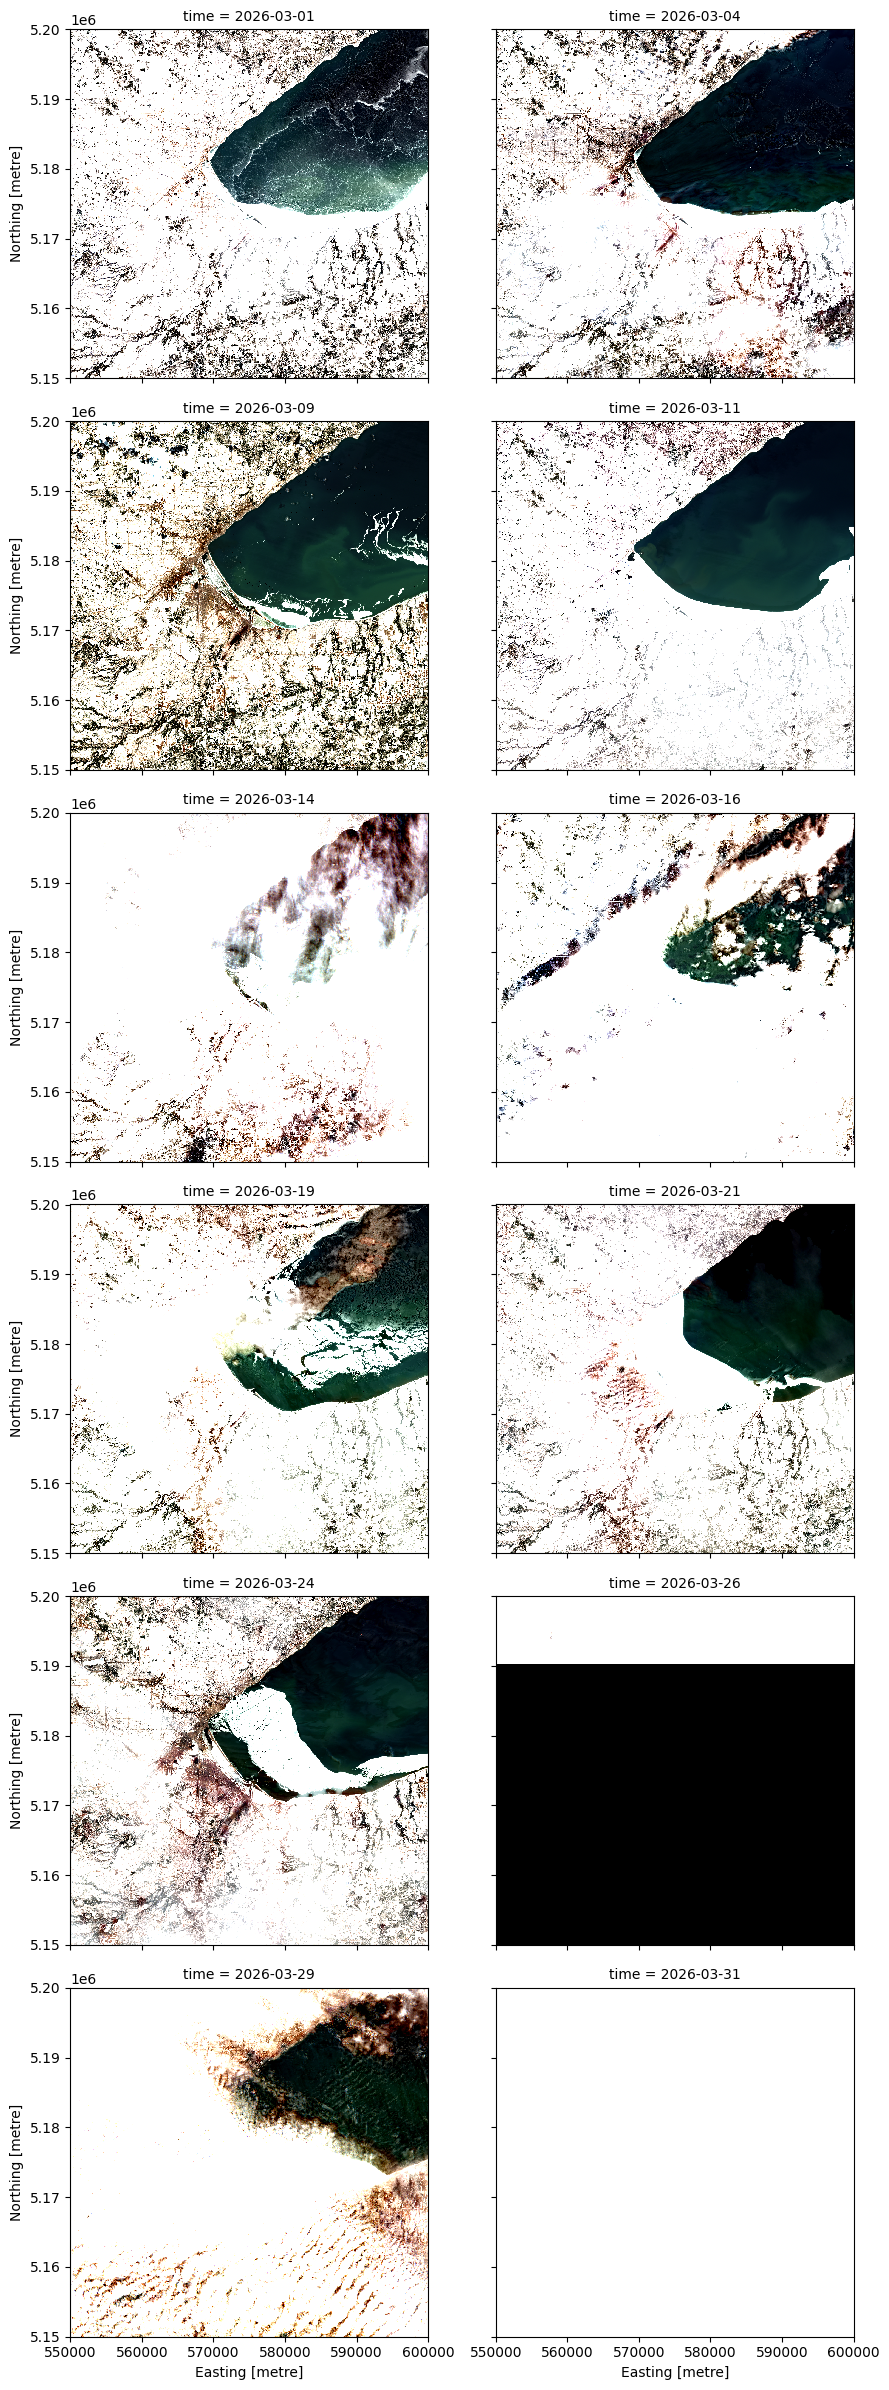

In [30]:
(
    subset.plot.imshow(
        rgb="band",
        col="time",
        col_wrap=2,
        vmin=0,
        vmax=2000,
        size=4,
        aspect=subset.shape[3] / subset.shape[2],
    )
)